# Notebook: Qualitative Evaluation (Expert Analysis) -- Experiment 1

In this notebook, the qualitative evaluation of Experiment 1 is conducted for the question-generation behind RQ1 and RQ3.

The notebook uses one evaluation setup with exactly 3 experts.

All rating categories are interpreted on a 1-5 Likert scale. Question-related and answer-related ratings are analyzed separately and as combined total scores.

## Initial Setup

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings
from statsmodels.stats.inter_rater import fleiss_kappa

warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("Set2")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.notebook_repr_html', True)

LIKERT_MIN = 1
LIKERT_MAX = 5
LIKERT_RANGE = (LIKERT_MIN, LIKERT_MAX)
EXPERT_IDS = [1, 2, 3]
ANALYSIS_SUFFIX = 'experts'

EXP1_QUESTION_COLS = [
    'q_relevance',
    'q_clarity',
    'q_answerability',
    'q_challenging',
    'q_value',
    'q_language',
]
EXP1_ANSWER_COLS = [
    'a_clarity',
    'a_language',
    'a_correctness',
]
EXP1_NUMERIC_COLS = EXP1_QUESTION_COLS + EXP1_ANSWER_COLS
EXP1_SCORE_COLS = ['question_total_score', 'answer_total_score', 'total_score']
SCORE_RANGES = {
    'question_total_score': (len(EXP1_QUESTION_COLS) * LIKERT_MIN, len(EXP1_QUESTION_COLS) * LIKERT_MAX),
    'answer_total_score': (len(EXP1_ANSWER_COLS) * LIKERT_MIN, len(EXP1_ANSWER_COLS) * LIKERT_MAX),
    'total_score': (len(EXP1_NUMERIC_COLS) * LIKERT_MIN, len(EXP1_NUMERIC_COLS) * LIKERT_MAX),
}

DISPLAY_LABELS = {
    'q_relevance': 'qRelevance',
    'q_clarity': 'qClarity',
    'q_answerability': 'qAnswerability',
    'q_challenging': 'qChallenging',
    'q_value': 'qValue',
    'q_language': 'qLanguage',
    'a_clarity': 'aClarity',
    'a_language': 'aLanguage',
    'a_correctness': 'aCorrectness',
    'question_total_score': 'qTotal',
    'answer_total_score': 'aTotal',
    'total_score': 'total',
}

BASE_PROJECT_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
qualitative_base_path = os.path.join(BASE_PROJECT_PATH, "20_experiments/60_analyses/csv/qualitative/exp1")
sampled_hints_path = os.path.join(BASE_PROJECT_PATH, "20_experiments/60_analyses/csv/sampled/exp1_sampled.csv")
output_base_path = os.path.join(BASE_PROJECT_PATH, "40_evaluation/exp1/qualitative")
output_tables_path = os.path.join(output_base_path, "tables")
output_plots_path = os.path.join(output_base_path, "plots")

for path in [output_tables_path, output_plots_path]:
    os.makedirs(path, exist_ok=True)

LABEL_MAPPING = {
    'anthropic': 'Anthropic',
    'openai': 'OpenAI',
    'deepseek': 'DeepSeek',
    'xai': 'xAI',
    'google': 'Google',
    'mcq': 'MCQ',
    'open_ended': 'Open-Ended',
    'layer1': 'Layer 1',
    'layer2': 'Layer 2',
    'layer3': 'Layer 3',
    'layer4': 'Layer 4',
    'layer5': 'Layer 5',
    'layer6': 'Layer 6',
    'layer7': 'Layer 7',
}

tables = {}
plots = {}

print("Setup completed successfully")
print(f"Output tables: {output_tables_path}")
print(f"Output plots: {output_plots_path}")
print(f"Experts configured: {EXPERT_IDS}")
print("Scale: 1-5 Likert per rating category")

Setup completed successfully
Output tables: /home/malde/git/question-generation/40_evaluation/exp1/qualitative/tables
Output plots: /home/malde/git/question-generation/40_evaluation/exp1/qualitative/plots
Experts configured: [1, 2, 3]
Scale: 1-5 Likert per rating category


In [2]:
# Utility Functions

def normalize_sample_id(series):
    return series.astype(str).str.extract(r'(\d+)')[0].str.zfill(3)


def create_seaborn_boxplot(data, x, y, ax, title, ylabel, xlabel, scale_range=None):
    plot_df = data[[x, y]].dropna().copy()
    if plot_df.empty:
        ax.set_title(f'{title} - No data', fontsize=12, fontweight='bold')
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        return

    colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854', '#ffd92f', '#e5c494', '#b3b3b3']
    order = sorted(plot_df[x].dropna().unique(), key=lambda value: str(value))
    palette = colors[:len(order)]

    sns.boxplot(
        data=plot_df,
        x=x,
        y=y,
        order=order,
        ax=ax,
        palette=palette,
        medianprops={'color': 'black', 'linewidth': 2.5, 'linestyle': ':'},
    )

    for i, value in enumerate(order):
        mean_val = plot_df.loc[plot_df[x] == value, y].mean()
        ax.scatter(i, mean_val, color='red', marker='D', s=50, zorder=3, edgecolor='darkred', linewidth=1)

    ax.set_xticklabels([LABEL_MAPPING.get(str(label), str(label)) for label in order], rotation=0)

    if scale_range is not None:
        padding = 0.1 if scale_range[1] <= 5 else 0.5
        ax.set_ylim(scale_range[0] - padding, scale_range[1] + padding)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11, labelpad=15)
    ax.set_xlabel(xlabel, fontsize=11, labelpad=10)
    ax.grid(True, alpha=0.3)


def create_heatmap(data, index_col, column_col, value_col, ax, title, cbar_label, scale_range=None):
    heatmap_mean = data.groupby([index_col, column_col])[value_col].mean().unstack()
    heatmap_std = data.groupby([index_col, column_col])[value_col].std().unstack()

    annot_matrix = heatmap_mean.copy().astype(object)
    for i in range(len(heatmap_mean.index)):
        for j in range(len(heatmap_mean.columns)):
            mean_val = heatmap_mean.iloc[i, j]
            std_val = heatmap_std.iloc[i, j]
            if pd.notna(mean_val) and pd.notna(std_val):
                annot_matrix.iloc[i, j] = f'{mean_val:.2f}\n({std_val:.2f})'
            elif pd.notna(mean_val):
                annot_matrix.iloc[i, j] = f'{mean_val:.2f}'
            else:
                annot_matrix.iloc[i, j] = ''

    yticklabels = [LABEL_MAPPING.get(str(label), str(label).title()) for label in heatmap_mean.index]
    xticklabels = [LABEL_MAPPING.get(str(label), str(label).title()) for label in heatmap_mean.columns]

    heatmap_kwargs = {
        'annot': annot_matrix,
        'fmt': '',
        'cmap': 'RdYlBu_r',
        'square': True,
        'linewidths': 0.5,
        'cbar_kws': {'shrink': 0.8, 'label': cbar_label},
        'annot_kws': {'size': 10, 'weight': 'bold'},
        'xticklabels': xticklabels,
        'yticklabels': yticklabels,
        'ax': ax,
    }

    if scale_range is not None:
        heatmap_kwargs['vmin'] = scale_range[0]
        heatmap_kwargs['vmax'] = scale_range[1]
        heatmap_kwargs['center'] = (scale_range[0] + scale_range[1]) / 2
    elif not heatmap_mean.empty:
        heatmap_kwargs['center'] = heatmap_mean.mean().mean()

    sns.heatmap(heatmap_mean, **heatmap_kwargs)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel(LABEL_MAPPING.get(column_col, column_col.replace('_', ' ').title()), fontsize=12, fontweight='bold')
    ax.set_ylabel(LABEL_MAPPING.get(index_col, index_col.replace('_', ' ').title()), fontsize=12, fontweight='bold')


print("Utility functions loaded successfully")

Utility functions loaded successfully


In [3]:
def enrich_exp1_metadata(df):
    if not os.path.exists(sampled_hints_path):
        raise FileNotFoundError(f"Sampled file not found at {sampled_hints_path}")

    sampled_df = pd.read_csv(sampled_hints_path).copy()
    sampled_df['sample_id'] = [f'{i + 1:03d}' for i in range(len(sampled_df))]

    df = df.copy()
    df['sample_id'] = normalize_sample_id(df['sample_id'])

    exp1_df = pd.merge(
        df,
        sampled_df[['sample_id', 'llm', 'layer', 'question_type', 'bloom_idx']],
        on='sample_id',
        how='left',
        suffixes=('', '_meta'),
    )

    for col in ['layer', 'question_type']:
        meta_col = f'{col}_meta'
        if meta_col in exp1_df.columns:
            if col in exp1_df.columns:
                exp1_df[col] = exp1_df[col].combine_first(exp1_df[meta_col])
            else:
                exp1_df[col] = exp1_df[meta_col]
            exp1_df = exp1_df.drop(columns=[meta_col])

    if 'layer' in exp1_df.columns:
        exp1_df['layer'] = pd.to_numeric(exp1_df['layer'], errors='coerce').astype('Int64')
        exp1_df['input_source'] = np.where(exp1_df['layer'].notna(), 'layer' + exp1_df['layer'].astype(str), pd.NA)

    if 'question_type' in exp1_df.columns:
        valid_types = ['mcq', 'open_ended']
        exp1_df['question_type'] = exp1_df['question_type'].where(exp1_df['question_type'].isin(valid_types), pd.NA)

    return exp1_df

In [4]:
def load_all_experts_data():
    experts_data = {}
    all_expert_dfs = []

    for expert_num in EXPERT_IDS:
        expert_key = f'expert_{expert_num}'
        expert_file = os.path.join(qualitative_base_path, f'exp1_eval_e{expert_num}.csv')

        if not os.path.exists(expert_file):
            print(f"Skip {expert_key}: file missing ({expert_file})")
            continue

        expert_df = pd.read_csv(expert_file)

        if expert_df.empty:
            print(f"Skip {expert_key}: empty CSV")
            continue

        first_row = expert_df.iloc[0]
        empty_count = first_row.apply(
            lambda v: pd.isna(v) or (isinstance(v, str) and v.strip() == '')
        ).sum()

        if empty_count >= 4:
            print(f"Skip {expert_key}: first data row has {empty_count} empty fields (>=4)")
            continue

        expert_df = enrich_exp1_metadata(expert_df)
        expert_df['expert'] = expert_key
        experts_data[expert_key] = expert_df.copy()
        all_expert_dfs.append(expert_df)

    if not all_expert_dfs:
        raise ValueError("No usable expert CSV found.")

    exp1_df = pd.concat(all_expert_dfs, ignore_index=True)
    return exp1_df, experts_data

In [5]:
# def load_all_experts_data():
#     experts_data = {}
#     all_expert_dfs = []

#     for expert_num in EXPERT_IDS:
#         expert_key = f'expert_{expert_num}'
#         expert_file = os.path.join(qualitative_base_path, f'exp1_eval_e{expert_num}.csv')

#         if not os.path.exists(expert_file):
#             raise FileNotFoundError(f'Missing required file: {expert_file}')

#         expert_df = pd.read_csv(expert_file)
#         expert_df = enrich_exp1_metadata(expert_df)
#         expert_df['expert'] = expert_key
#         experts_data[expert_key] = expert_df.copy()
#         all_expert_dfs.append(expert_df)

#     exp1_df = pd.concat(all_expert_dfs, ignore_index=True)
#     return exp1_df, experts_data

In [6]:
def clean_numeric_data(df, numeric_cols):
    invalid_values = [
        '??', '???', '?', '????', '', ' ', 'nan', 'NaN', 'NULL', 'null',
        'None', 'NONE', 'n/a', 'N/A', '#N/A', '#NULL!',
        'undefined', 'UNDEFINED', '-', '--', '---', '-99',
    ]

    df = df.copy()
    for col in numeric_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().replace(invalid_values, np.nan)
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df.loc[(df[col] < LIKERT_MIN) | (df[col] > LIKERT_MAX), col] = np.nan
    return df


def calculate_exp1_scores(df):
    df = df.copy()
    df['question_total_score'] = df[EXP1_QUESTION_COLS].sum(axis=1, min_count=len(EXP1_QUESTION_COLS))
    df['answer_total_score'] = df[EXP1_ANSWER_COLS].sum(axis=1, min_count=len(EXP1_ANSWER_COLS))
    df['total_score'] = df[EXP1_NUMERIC_COLS].sum(axis=1, min_count=len(EXP1_NUMERIC_COLS))
    return df

In [7]:
def calculate_fleiss_kappa(expert_dfs_dict, criteria_cols):
    results = []
    
    expert_keys = sorted(expert_dfs_dict.keys())
    
    if len(expert_keys) < 2:
        print("Need at least 2 experts for agreement analysis")
        return pd.DataFrame()
    
    common_ids = None
    for expert_key in expert_keys:
        df = expert_dfs_dict[expert_key]
        if 'sample_id' in df.columns:
            ids = set(normalize_sample_id(df['sample_id']).dropna())
            if common_ids is None:
                common_ids = ids
            else:
                common_ids = common_ids & ids
    
    if not common_ids:
        print("No common sample_ids found across experts")
        return pd.DataFrame()
    
    common_ids = sorted(list(common_ids))
    print(f"Analyzing {len(expert_keys)} experts with {len(common_ids)} common samples")
    
    for criterion in criteria_cols:
        ratings = []
        for sample_id in common_ids:
            sample_ratings = []
            valid_sample = True
            
            for expert_key in expert_keys:
                df = expert_dfs_dict[expert_key].copy()
                df['sample_id'] = normalize_sample_id(df['sample_id'])
                sample_rows = df[df['sample_id'] == sample_id]
                if sample_rows.empty:
                    valid_sample = False
                    break
                rating = pd.to_numeric(sample_rows.iloc[0][criterion], errors='coerce')
                if pd.isna(rating) or rating < LIKERT_MIN or rating > LIKERT_MAX:
                    valid_sample = False
                    break
                sample_ratings.append(int(round(rating)))
            
            if valid_sample and len(sample_ratings) == len(expert_keys):
                ratings.append(sample_ratings)
        
        if len(ratings) >= 2:
            ratings_array = np.array(ratings)
            fleiss_table = np.zeros((len(ratings), LIKERT_MAX - LIKERT_MIN + 1))
            
            for i, item_ratings in enumerate(ratings):
                for rating in item_ratings:
                    fleiss_table[i, int(rating) - LIKERT_MIN] += 1
            
            all_identical = np.all(
                (fleiss_table == np.max(fleiss_table, axis=1, keepdims=True)) | (fleiss_table == 0),
                axis=1,
            )
            if np.all(all_identical):
                kappa = 1.0
            else:
                kappa = fleiss_kappa(fleiss_table)
            
            level = (
                "Slight" if kappa < 0.2 else
                "Fair" if kappa < 0.4 else
                "Moderate" if kappa < 0.6 else
                "Substantial" if kappa < 0.8 else
                "Almost Perfect"
            )
            
            results.append({
                'Criterion': criterion,
                'Display_Label': DISPLAY_LABELS.get(criterion, criterion),
                'Fleiss_Kappa': round(kappa, 3),
                'Agreement_Level': level,
                'N_Items': len(ratings),
                'N_Raters': len(expert_keys),
                'Mean_Rating': round(np.mean(ratings_array), 2),
                'Std_Rating': round(np.std(ratings_array), 2)
            })
    
    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_df['Rating_Group'] = np.where(
            results_df['Criterion'].isin(EXP1_QUESTION_COLS),
            'Question',
            'Answer',
        )
    return results_df

print("Agreement helper loaded successfully")

Agreement helper loaded successfully


## Data Loading and Configuration

In [8]:
print(f"Loading unified expert data (Experts {EXPERT_IDS[0]}-{EXPERT_IDS[-1]})")
exp1_df, experts_data = load_all_experts_data()
agreement_available = len(experts_data) >= 2
analysis_suffix = ANALYSIS_SUFFIX

exp1_df = clean_numeric_data(exp1_df, EXP1_NUMERIC_COLS)
exp1_df = calculate_exp1_scores(exp1_df)
criteria = EXP1_NUMERIC_COLS + EXP1_SCORE_COLS

exp1_filled = exp1_df[EXP1_NUMERIC_COLS].notna().sum().sum()
exp1_total = len(exp1_df) * len(EXP1_NUMERIC_COLS)
completion_pct = (100 * exp1_filled / exp1_total) if exp1_total else 0

print(f"\nData loaded successfully!")
print(f"Experiment 1: {len(exp1_df)} rows, {completion_pct:.1f}% rating completion")
print(f"Experts loaded: {list(experts_data.keys())}")

if 'llm' in exp1_df.columns:
    print(f"\nDistribution:")
    print(f"  LLMs: {list(exp1_df['llm'].dropna().unique())}")
if 'question_type' in exp1_df.columns:
    print(f"  Question Types: {list(exp1_df['question_type'].dropna().unique())}")
if 'layer' in exp1_df.columns:
    print(f"  Layers (OSI): {sorted(exp1_df['layer'].dropna().unique())}")

if 'layer' in exp1_df.columns and 'input_source' not in exp1_df.columns:
    exp1_df['input_source'] = 'layer' + exp1_df['layer'].astype(str)

Loading unified expert data (Experts 1-3)
Skip expert_2: first data row has 11 empty fields (>=4)
Skip expert_3: first data row has 11 empty fields (>=4)

Data loaded successfully!
Experiment 1: 24 rows, 100.0% rating completion
Experts loaded: ['expert_1']

Distribution:
  LLMs: ['anthropic', 'deepseek', 'openai', 'xai']
  Question Types: ['mcq', 'open_ended']
  Layers (OSI): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


# Experiment 1: OSI Layer-Based Analysis

Analysis of LLM question generation quality using OSI layer source materials.

In [9]:
print("EXPERIMENT 1 - DESCRIPTIVE STATISTICS")
print("="*60)

criteria = EXP1_NUMERIC_COLS + EXP1_SCORE_COLS

exp1_stats = exp1_df[criteria].describe().round(2)
tables[f'exp1_overall_stats_{analysis_suffix}'] = exp1_stats
print("\nOverall Statistics:")
display(exp1_stats)

EXPERIMENT 1 - DESCRIPTIVE STATISTICS

Overall Statistics:


,q_relevance,q_clarity,q_answerability,q_challenging,q_value,q_language,a_clarity,a_language,a_correctness,question_total_score,answer_total_score,total_score
count,24.00,24.00,24.00,24.00,24.00,24.00,24.00,24.00,24.00,24.00,24.00,24.00
mean,4.00,4.33,3.75,2.75,3.08,4.71,4.71,4.50,4.29,22.62,13.50,36.12
std,0.98,1.09,1.62,1.59,1.47,0.69,0.62,0.88,1.04,2.79,1.79,3.39
min,2.00,2.00,1.00,1.00,1.00,3.00,3.00,2.00,2.00,16.00,9.00,29.00
25%,3.00,4.00,2.00,1.00,2.00,5.00,5.00,4.00,3.75,21.75,12.00,34.00
50%,4.00,5.00,5.00,2.00,3.00,5.00,5.00,5.00,5.00,22.00,14.00,37.00
75%,5.00,5.00,5.00,4.25,5.00,5.00,5.00,5.00,5.00,24.00,15.00,39.00
max,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,27.00,15.00,42.00


In [10]:
# Statistics by LLM
exp1_llm_stats = exp1_df.groupby('llm')[criteria].agg(['mean', 'std', 'median', 'count']).round(2)
tables[f'exp1_llm_stats_{analysis_suffix}'] = exp1_llm_stats
print("\nStatistics by LLM:")
display(exp1_llm_stats)


Statistics by LLM:


q_relevance                    q_clarity                     \
                 mean   std median count      mean   std median count   
llm                                                                     
anthropic        3.67  1.03    4.0     6      4.83  0.41    5.0     6   
deepseek         4.17  0.75    4.0     6      4.00  1.55    5.0     6   
openai           3.17  0.75    3.0     6      4.00  0.89    4.0     6   
xai              5.00  0.00    5.0     6      4.50  1.22    5.0     6   

          q_answerability                    q_challenging                     \
                     mean   std median count          mean   std median count   
llm                                                                             
anthropic            4.50  1.22    5.0     6          2.33  1.21    2.5     6   
deepseek             3.33  1.97    4.0     6          2.83  1.72    2.0     6   
openai               3.17  1.72    3.0     6          3.33  1.86    3.5     6   
xai                  4.00  1.55    5.0     6          2.50  1.76    2.0     6   

          q_value                    q_language                    a_clarity  \
             mean   std median count       mean   std median count      mean   
llm                                                                            
anthropic    3.17  1.17    3.0     6       5.00  0.00    5.0     6      5.00   
deepseek     2.67  1.37    2.5     6       5.00  0.00    5.0     6      4.67   
openai       3.83  1.33    4.0     6       4.17  0.98    4.5     6      4.33   
xai          2.67  1.97    2.0     6       4.67  0.82    5.0     6      4.83   

                             a_language                    a_correctness  \
            std median count       mean   std median count          mean   
llm                                                                        
anthropic  0.00    5.0     6       4.67  0.82    5.0     6          4.50   
deepseek   0.82    5.0     6       5.00  0.00    5.0     6          4.17   
openai     0.82    4.5     6       4.17  0.98    4.5     6          4.00   
xai        0.41    5.0     6       4.17  1.17    4.5     6          4.50   

                             question_total_score                     \
            std median count                 mean   std median count   
llm                                                                    
anthropic  0.84    5.0     6                23.50  2.59   23.0     6   
deepseek   0.98    4.5     6                22.00  3.58   23.0     6   
openai     1.26    4.5     6                21.67  3.01   22.5     6   
xai        1.22    5.0     6                23.33  2.07   22.0     6   

          answer_total_score                    total_score                     
                        mean   std median count        mean   std median count  
llm                                                                             
anthropic              14.17  1.33   15.0     6       37.67  2.73   37.5     6  
deepseek               13.83  1.60   14.5     6       35.83  3.82   37.0     6  
openai                 12.50  2.07   12.5     6       34.17  3.31   34.5     6  
xai                    13.50  2.07   14.5     6       36.83  3.43   37.0     6

In [11]:
# LLM ranking
ranking_cols = ['question_total_score', 'answer_total_score', 'total_score']
exp1_llm_means = exp1_df.groupby('llm')[ranking_cols].mean().round(2)
exp1_llm_means['combined_mean'] = exp1_llm_means.mean(axis=1)
exp1_llm_overall = exp1_llm_means.sort_values('combined_mean', ascending=False)
tables[f'exp1_llm_ranking_{analysis_suffix}'] = exp1_llm_overall

print("\nOverall LLM Ranking:")
display(exp1_llm_overall)


Overall LLM Ranking:


,question_total_score,answer_total_score,total_score,combined_mean
llm,,,,
anthropic,23.50,14.17,37.67,25.113333
xai,23.33,13.50,36.83,24.553333
deepseek,22.00,13.83,35.83,23.886667
openai,21.67,12.50,34.17,22.780000


In [12]:
# Statistics by Input Source (OSI Layer)
# exp1_source_stats = exp1_df.groupby('input_source')[criteria].agg(['mean', 'std', 'median', 'count']).round(2)
# tables[f'exp1_source_stats_{analysis_suffix}'] = exp1_source_stats
# print("\nStatistics by Input Source (OSI Layer):")
# display(exp1_source_stats)

In [13]:
# Statistics by Question Type
exp1_question_type_stats = exp1_df.groupby('question_type')[criteria].agg(['mean', 'std', 'median', 'count']).round(2)
tables[f'exp1_question_type_stats_{analysis_suffix}'] = exp1_question_type_stats
print("\nStatistics by Question Type:")
display(exp1_question_type_stats)


Statistics by Question Type:


q_relevance                    q_clarity                     \
                     mean   std median count      mean   std median count   
question_type                                                               
mcq                  4.25  0.62    4.0    12      4.75  0.62    5.0    12   
open_ended           3.75  1.22    3.5    12      3.92  1.31    4.5    12   

              q_answerability                    q_challenging               \
                         mean   std median count          mean   std median   
question_type                                                                 
mcq                      4.92  0.29    5.0    12           1.5  0.52    1.5   
open_ended               2.58  1.56    2.0    12           4.0  1.28    4.5   

                    q_value                    q_language                     \
              count    mean   std median count       mean   std median count   
question_type                                                                  
mcq              12    2.00  0.85    2.0    12       4.83  0.58    5.0    12   
open_ended       12    4.17  1.11    5.0    12       4.58  0.79    5.0    12   

              a_clarity                    a_language                     \
                   mean   std median count       mean   std median count   
question_type                                                              
mcq                4.92  0.29    5.0    12       4.75  0.87    5.0    12   
open_ended         4.50  0.80    5.0    12       4.25  0.87    4.5    12   

              a_correctness                    question_total_score        \
                       mean   std median count                 mean   std   
question_type                                                               
mcq                    4.75  0.87    5.0    12                22.25  2.26   
open_ended             3.83  1.03    4.0    12                23.00  3.30   

                           answer_total_score                    total_score  \
              median count               mean   std median count        mean   
question_type                                                                  
mcq             22.0    12              14.42  1.16   15.0    12       36.67   
open_ended      22.5    12              12.58  1.88   13.0    12       35.58   

                                  
                std median count  
question_type                     
mcq            2.61   37.0    12  
open_ended     4.08   34.5    12

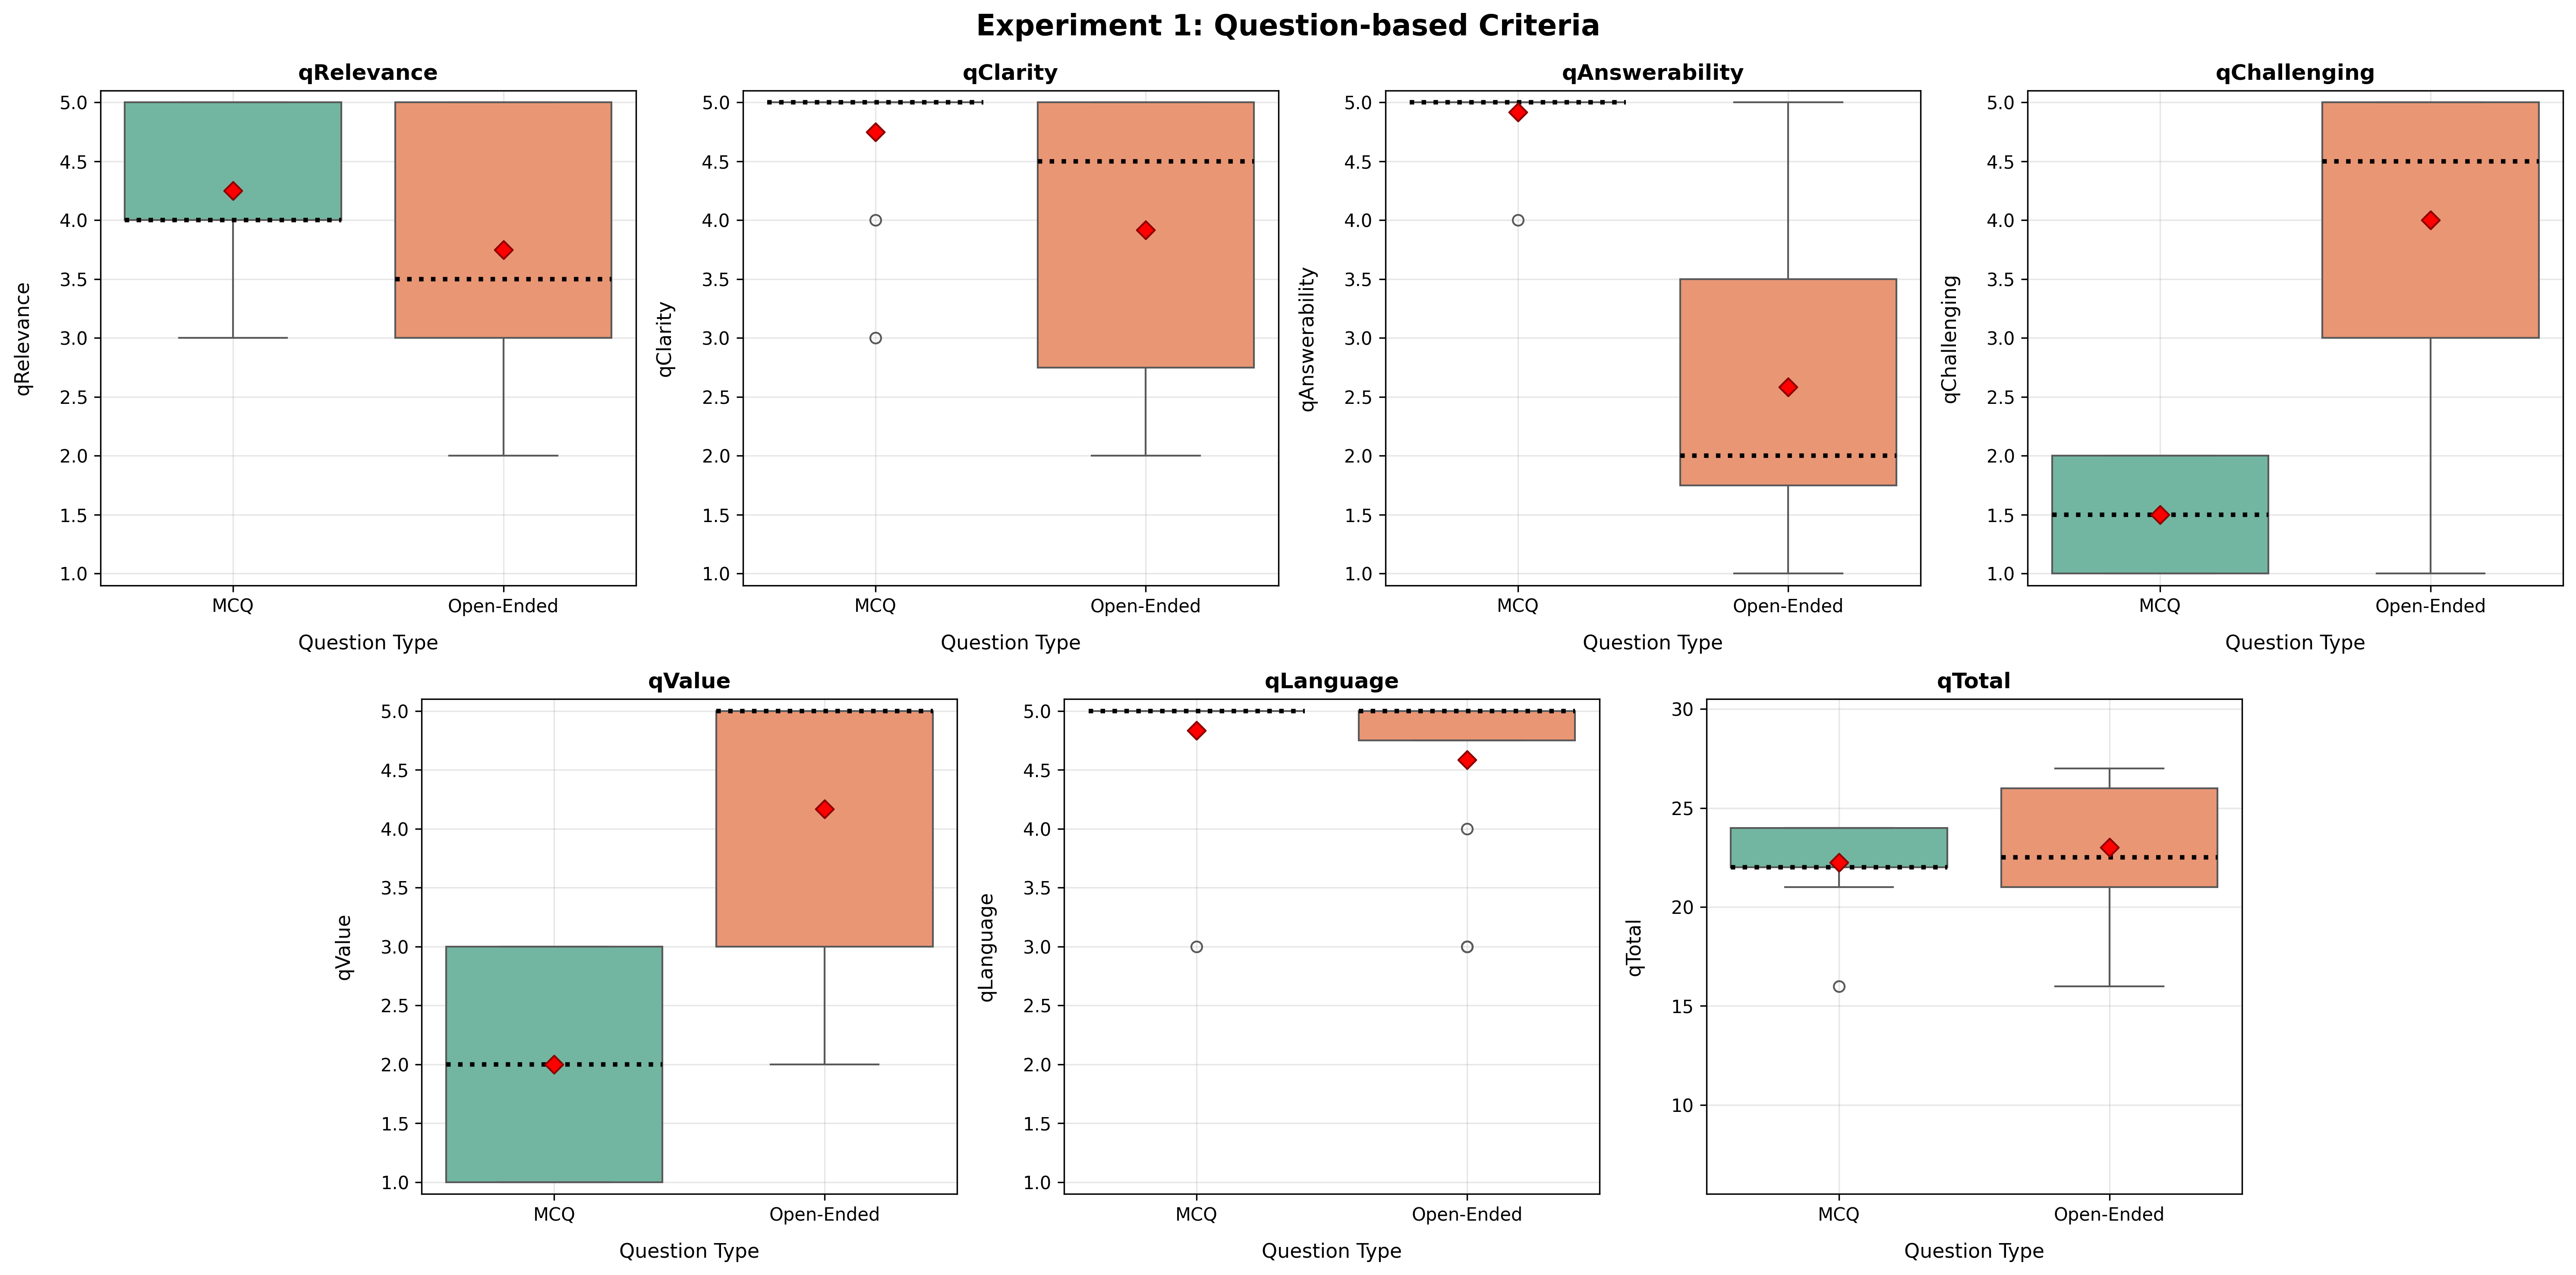

In [ ]:
question_plot_metrics = EXP1_QUESTION_COLS + ['question_total_score']

fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, 8)

axes = [
    fig.add_subplot(gs[0, 0:2]),
    fig.add_subplot(gs[0, 2:4]),
    fig.add_subplot(gs[0, 4:6]),
    fig.add_subplot(gs[0, 6:8]),
    fig.add_subplot(gs[1, 1:3]),
    fig.add_subplot(gs[1, 3:5]),
    fig.add_subplot(gs[1, 5:7]),
]

plots[f'exp1_question_bundle_question_type_{analysis_suffix}'] = fig

for i, criterion in enumerate(question_plot_metrics):
    scale_range = SCORE_RANGES.get(criterion, LIKERT_RANGE)
    create_seaborn_boxplot(
        exp1_df,
        'question_type',
        criterion,
        axes[i],
        DISPLAY_LABELS.get(criterion, criterion.title()),
        DISPLAY_LABELS.get(criterion, criterion.title()),
        'Question Type',
        scale_range=scale_range,
    )

plt.suptitle('Experiment 1: Question-based Criteria', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

In [15]:
# question_plot_metrics = EXP1_QUESTION_COLS + ['question_total_score']

# fig, axes = plt.subplots(2, 4, figsize=(20, 10))
# axes = axes.flatten()
# plots[f'exp1_question_bundle_llm_{analysis_suffix}'] = fig

# for i, criterion in enumerate(question_plot_metrics):
#     scale_range = SCORE_RANGES.get(criterion, LIKERT_RANGE)
#     create_seaborn_boxplot(
#         exp1_df,
#         'llm',
#         criterion,
#         axes[i],
#         DISPLAY_LABELS.get(criterion, criterion.title()),
#         DISPLAY_LABELS.get(criterion, criterion.title()),
#         'LLM',
#         scale_range=scale_range,
#     )

# for j in range(len(question_plot_metrics), len(axes)):
#     axes[j].set_axis_off()

# plt.suptitle('Experiment 1: Question-based Criteria', fontsize=16, fontweight='bold', y=0.98)
# plt.tight_layout()
# plt.subplots_adjust(top=0.92)
# plt.show()

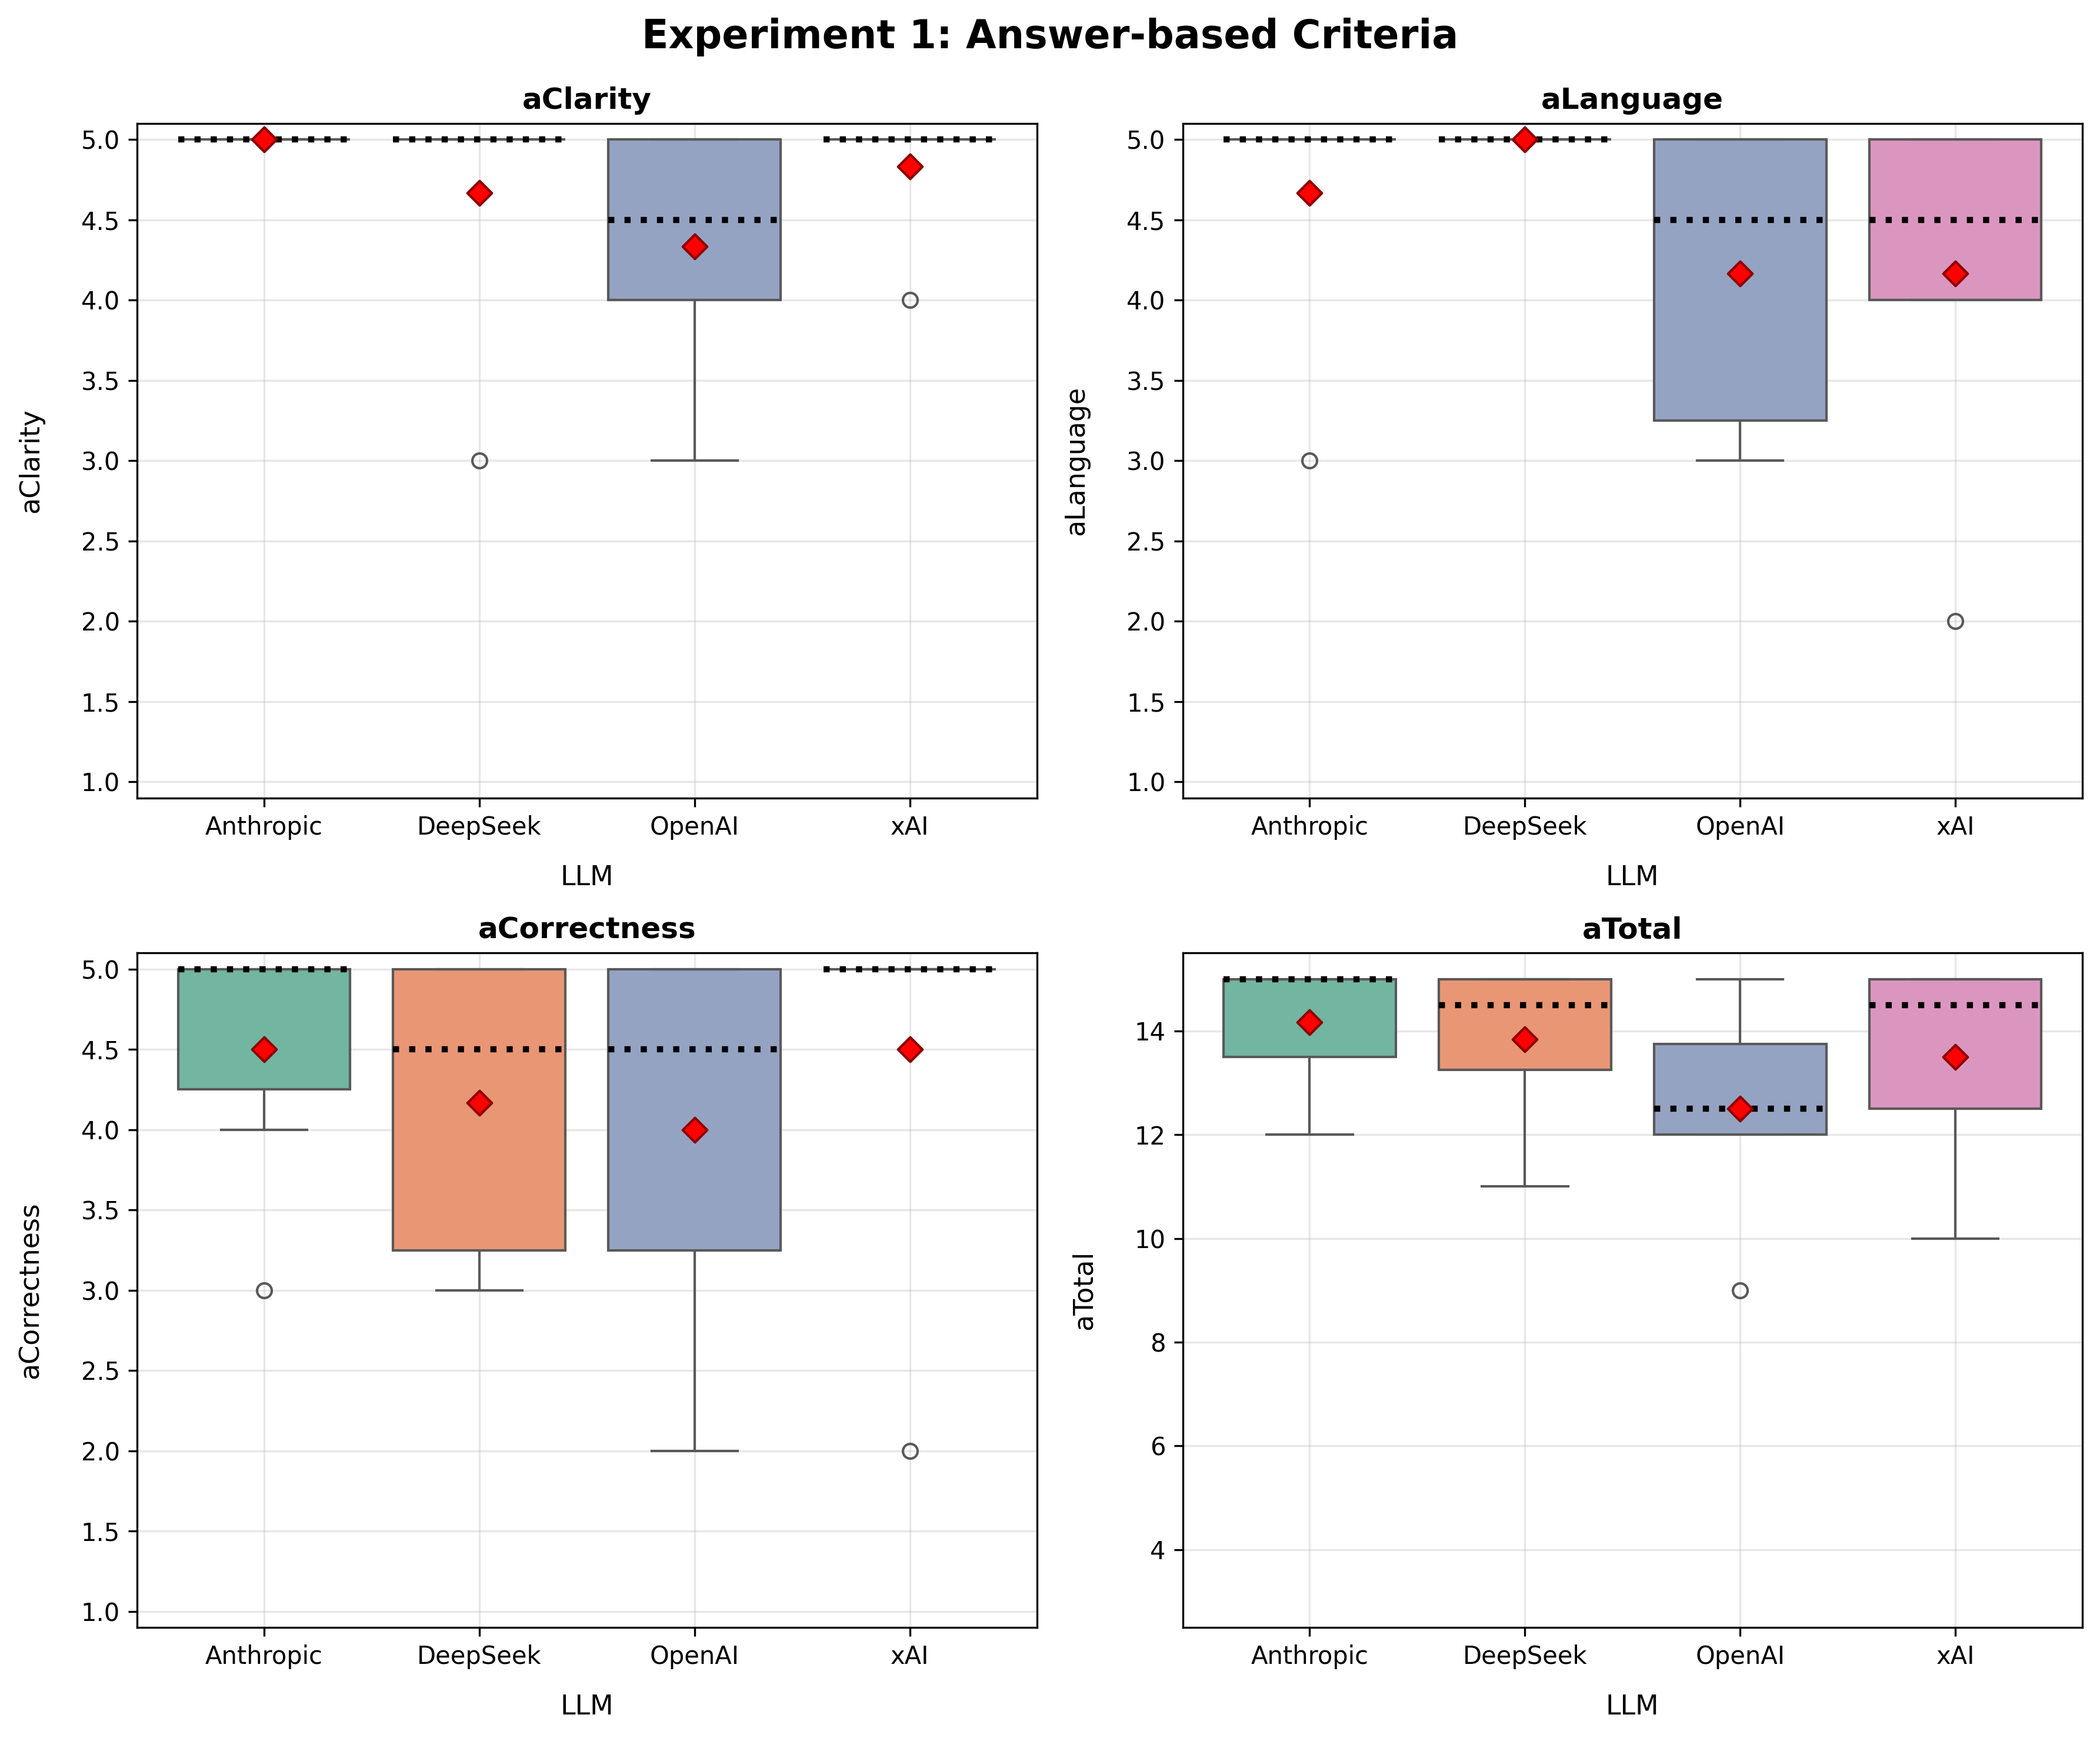

In [16]:
answer_plot_metrics = EXP1_ANSWER_COLS + ['answer_total_score']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
plots[f'exp1_answer_bundle_llm_{analysis_suffix}'] = fig

for i, criterion in enumerate(answer_plot_metrics):
    scale_range = SCORE_RANGES.get(criterion, LIKERT_RANGE)
    create_seaborn_boxplot(
        exp1_df,
        'llm',
        criterion,
        axes[i],
        DISPLAY_LABELS.get(criterion, criterion.title()),
        DISPLAY_LABELS.get(criterion, criterion.title()),
        'LLM',
        scale_range=scale_range,
    )

plt.suptitle('Experiment 1: Answer-based Criteria', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

In [ ]:
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, 8)

axes = [
    fig.add_subplot(gs[0, 0:2]),
    fig.add_subplot(gs[0, 2:4]),
    fig.add_subplot(gs[0, 4:6]),
    fig.add_subplot(gs[0, 6:8]),
    fig.add_subplot(gs[1, 1:3]),
    fig.add_subplot(gs[1, 3:5]),
    fig.add_subplot(gs[1, 5:7]),
]

plots[f'exp1_question_bundle_llm_{analysis_suffix}'] = fig

for i, criterion in enumerate(question_plot_metrics):
    scale_range = SCORE_RANGES.get(criterion, LIKERT_RANGE)
    create_seaborn_boxplot(
        exp1_df,
        'llm',
        criterion,
        axes[i],
        DISPLAY_LABELS.get(criterion, criterion.title()),
        DISPLAY_LABELS.get(criterion, criterion.title()),
        'LLM',
        scale_range=scale_range,
    )

plt.suptitle('Experiment 1: Question-based Criteria', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

In [ ]:
# fig, axes = plt.subplots(2, 4, figsize=(20, 10))
# axes = axes.flatten()
# plots[f'exp1_question_bundle_question_type_{analysis_suffix}'] = fig

# for i, criterion in enumerate(question_plot_metrics):
#     scale_range = SCORE_RANGES.get(criterion, LIKERT_RANGE)
#     create_seaborn_boxplot(
#         exp1_df,
#         'question_type',
#         criterion,
#         axes[i],
#         DISPLAY_LABELS.get(criterion, criterion.title()),
#         DISPLAY_LABELS.get(criterion, criterion.title()),
#         'Question Type',
#         scale_range=scale_range,
#     )

# for j in range(len(question_plot_metrics), len(axes)):
#     axes[j].set_axis_off()

# plt.suptitle('Experiment 1: Question-based Criteria', fontsize=16, fontweight='bold', y=0.98)
# plt.tight_layout()
# plt.subplots_adjust(top=0.92)
# plt.show()

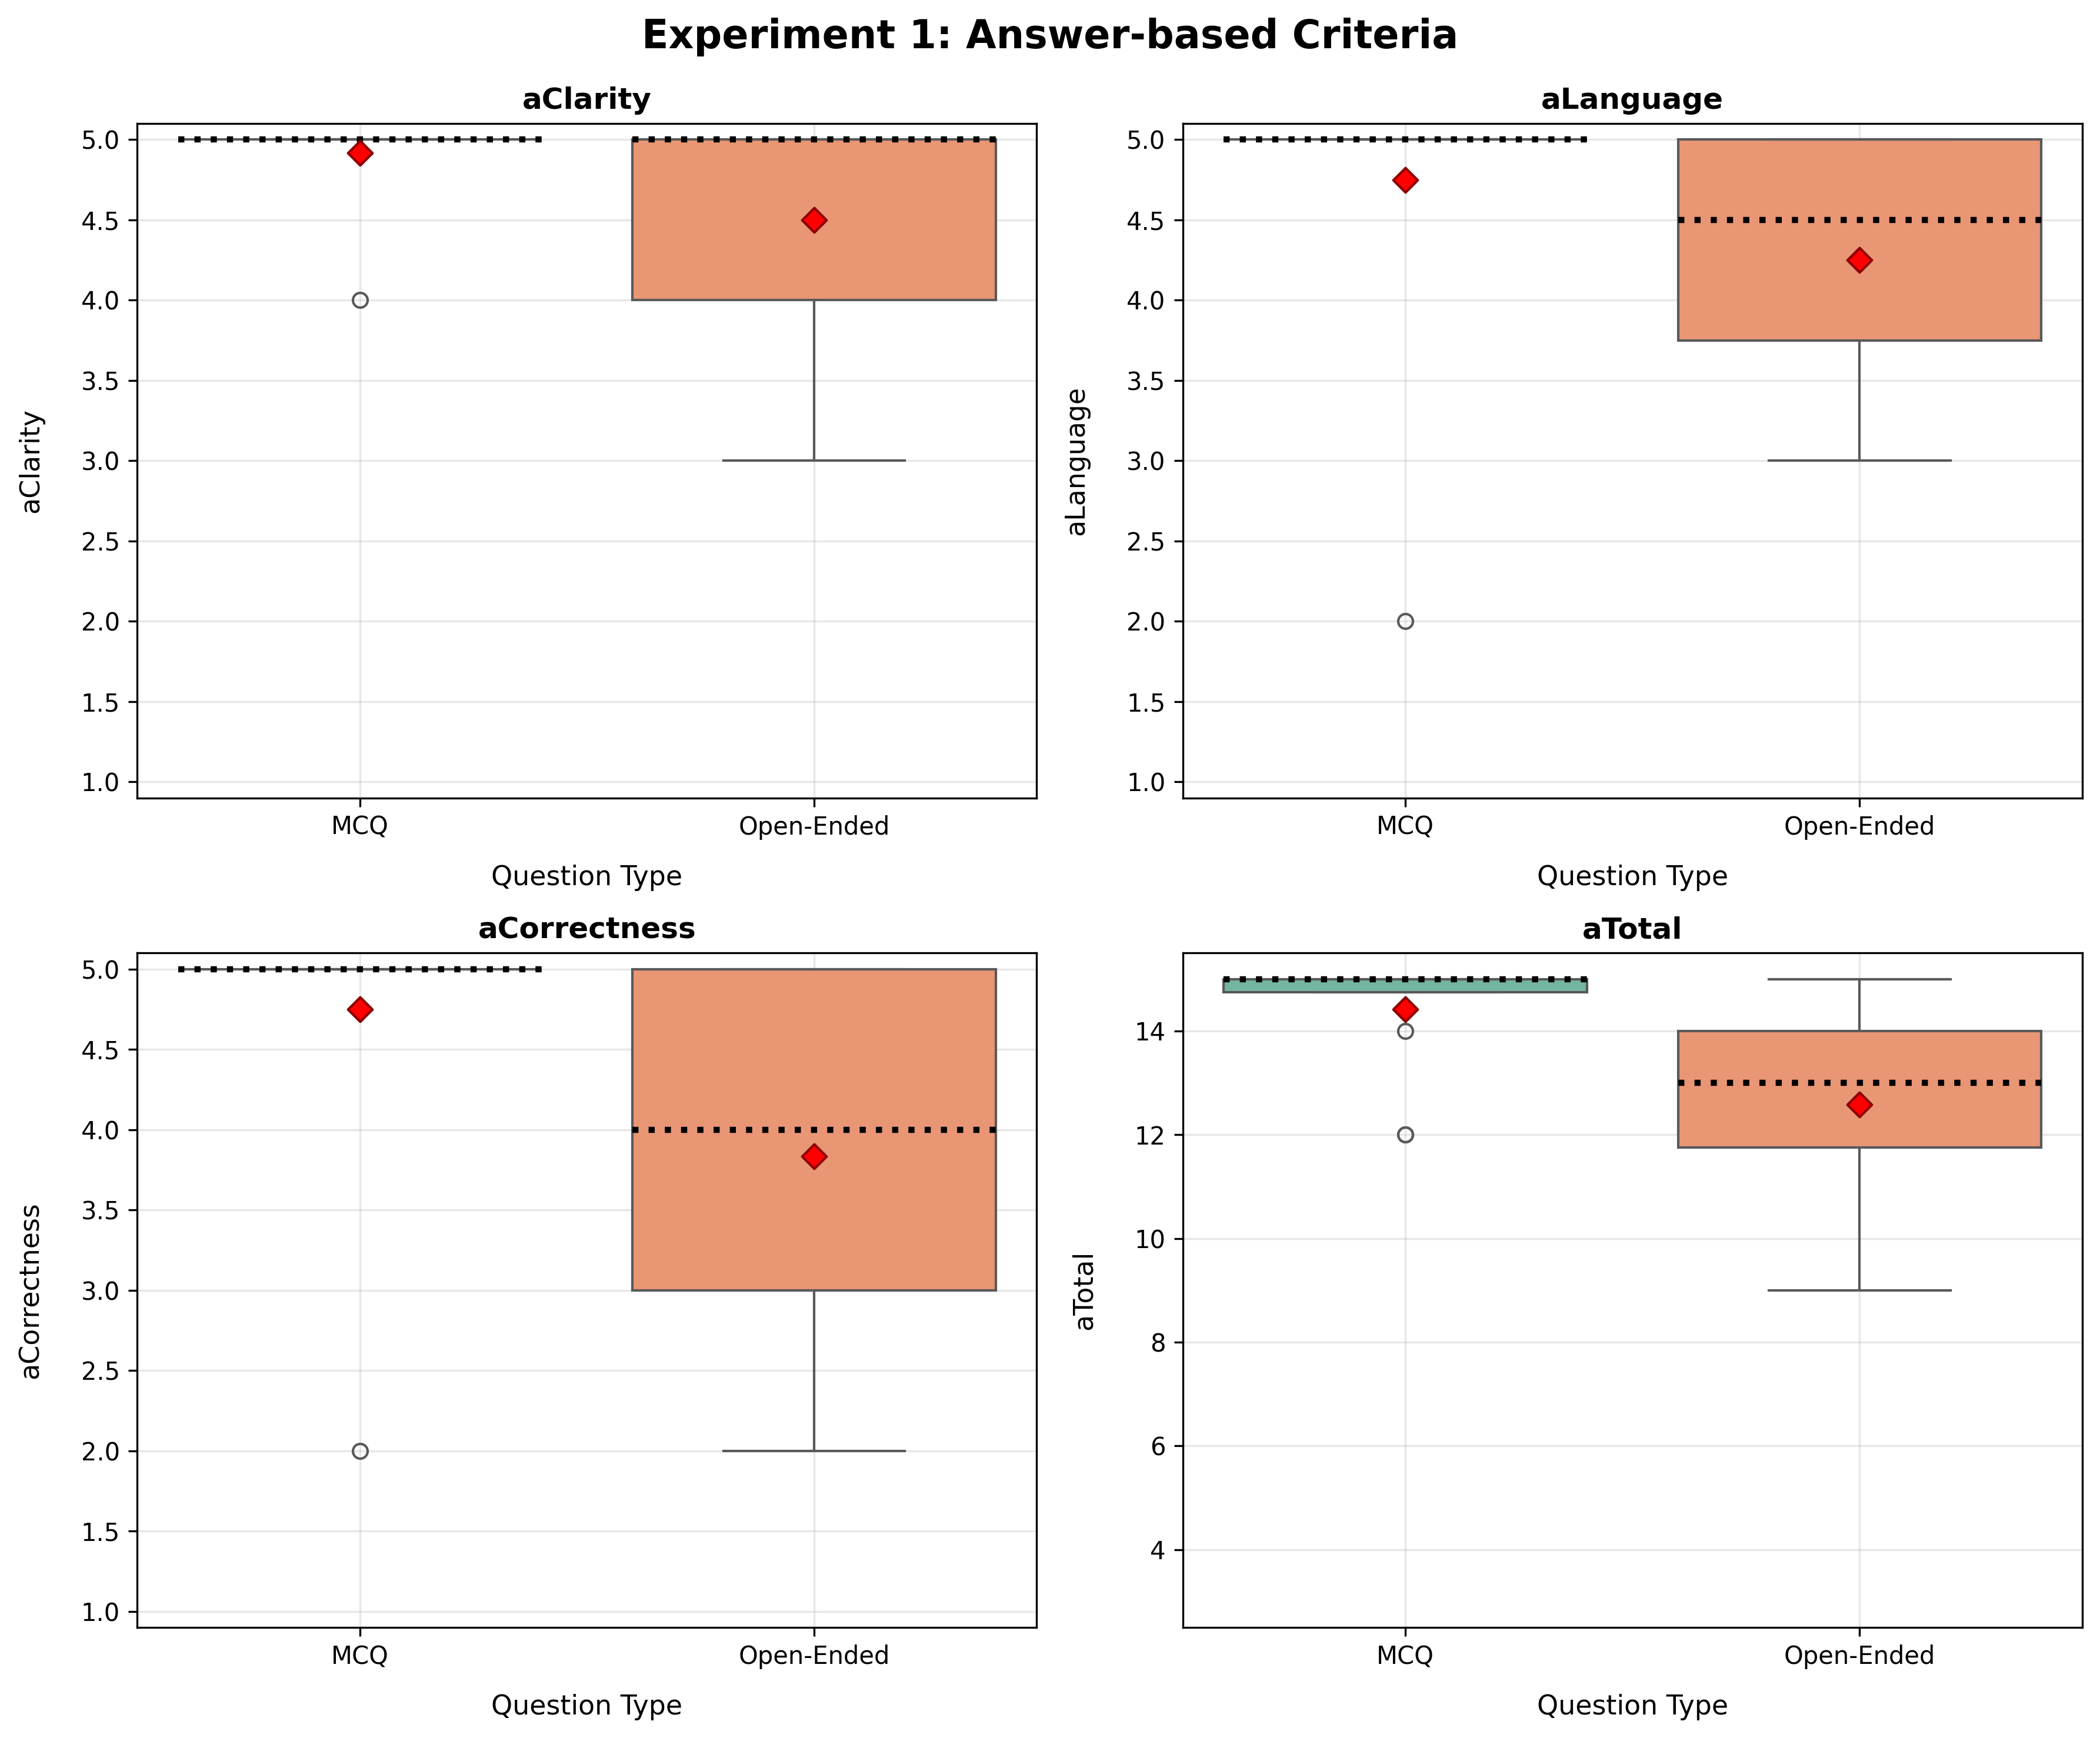

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
plots[f'exp1_answer_bundle_question_type_{analysis_suffix}'] = fig

for i, criterion in enumerate(answer_plot_metrics):
    scale_range = SCORE_RANGES.get(criterion, LIKERT_RANGE)
    create_seaborn_boxplot(
        exp1_df,
        'question_type',
        criterion,
        axes[i],
        DISPLAY_LABELS.get(criterion, criterion.title()),
        DISPLAY_LABELS.get(criterion, criterion.title()),
        'Question Type',
        scale_range=scale_range,
    )

plt.suptitle('Experiment 1: Answer-based Criteria', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

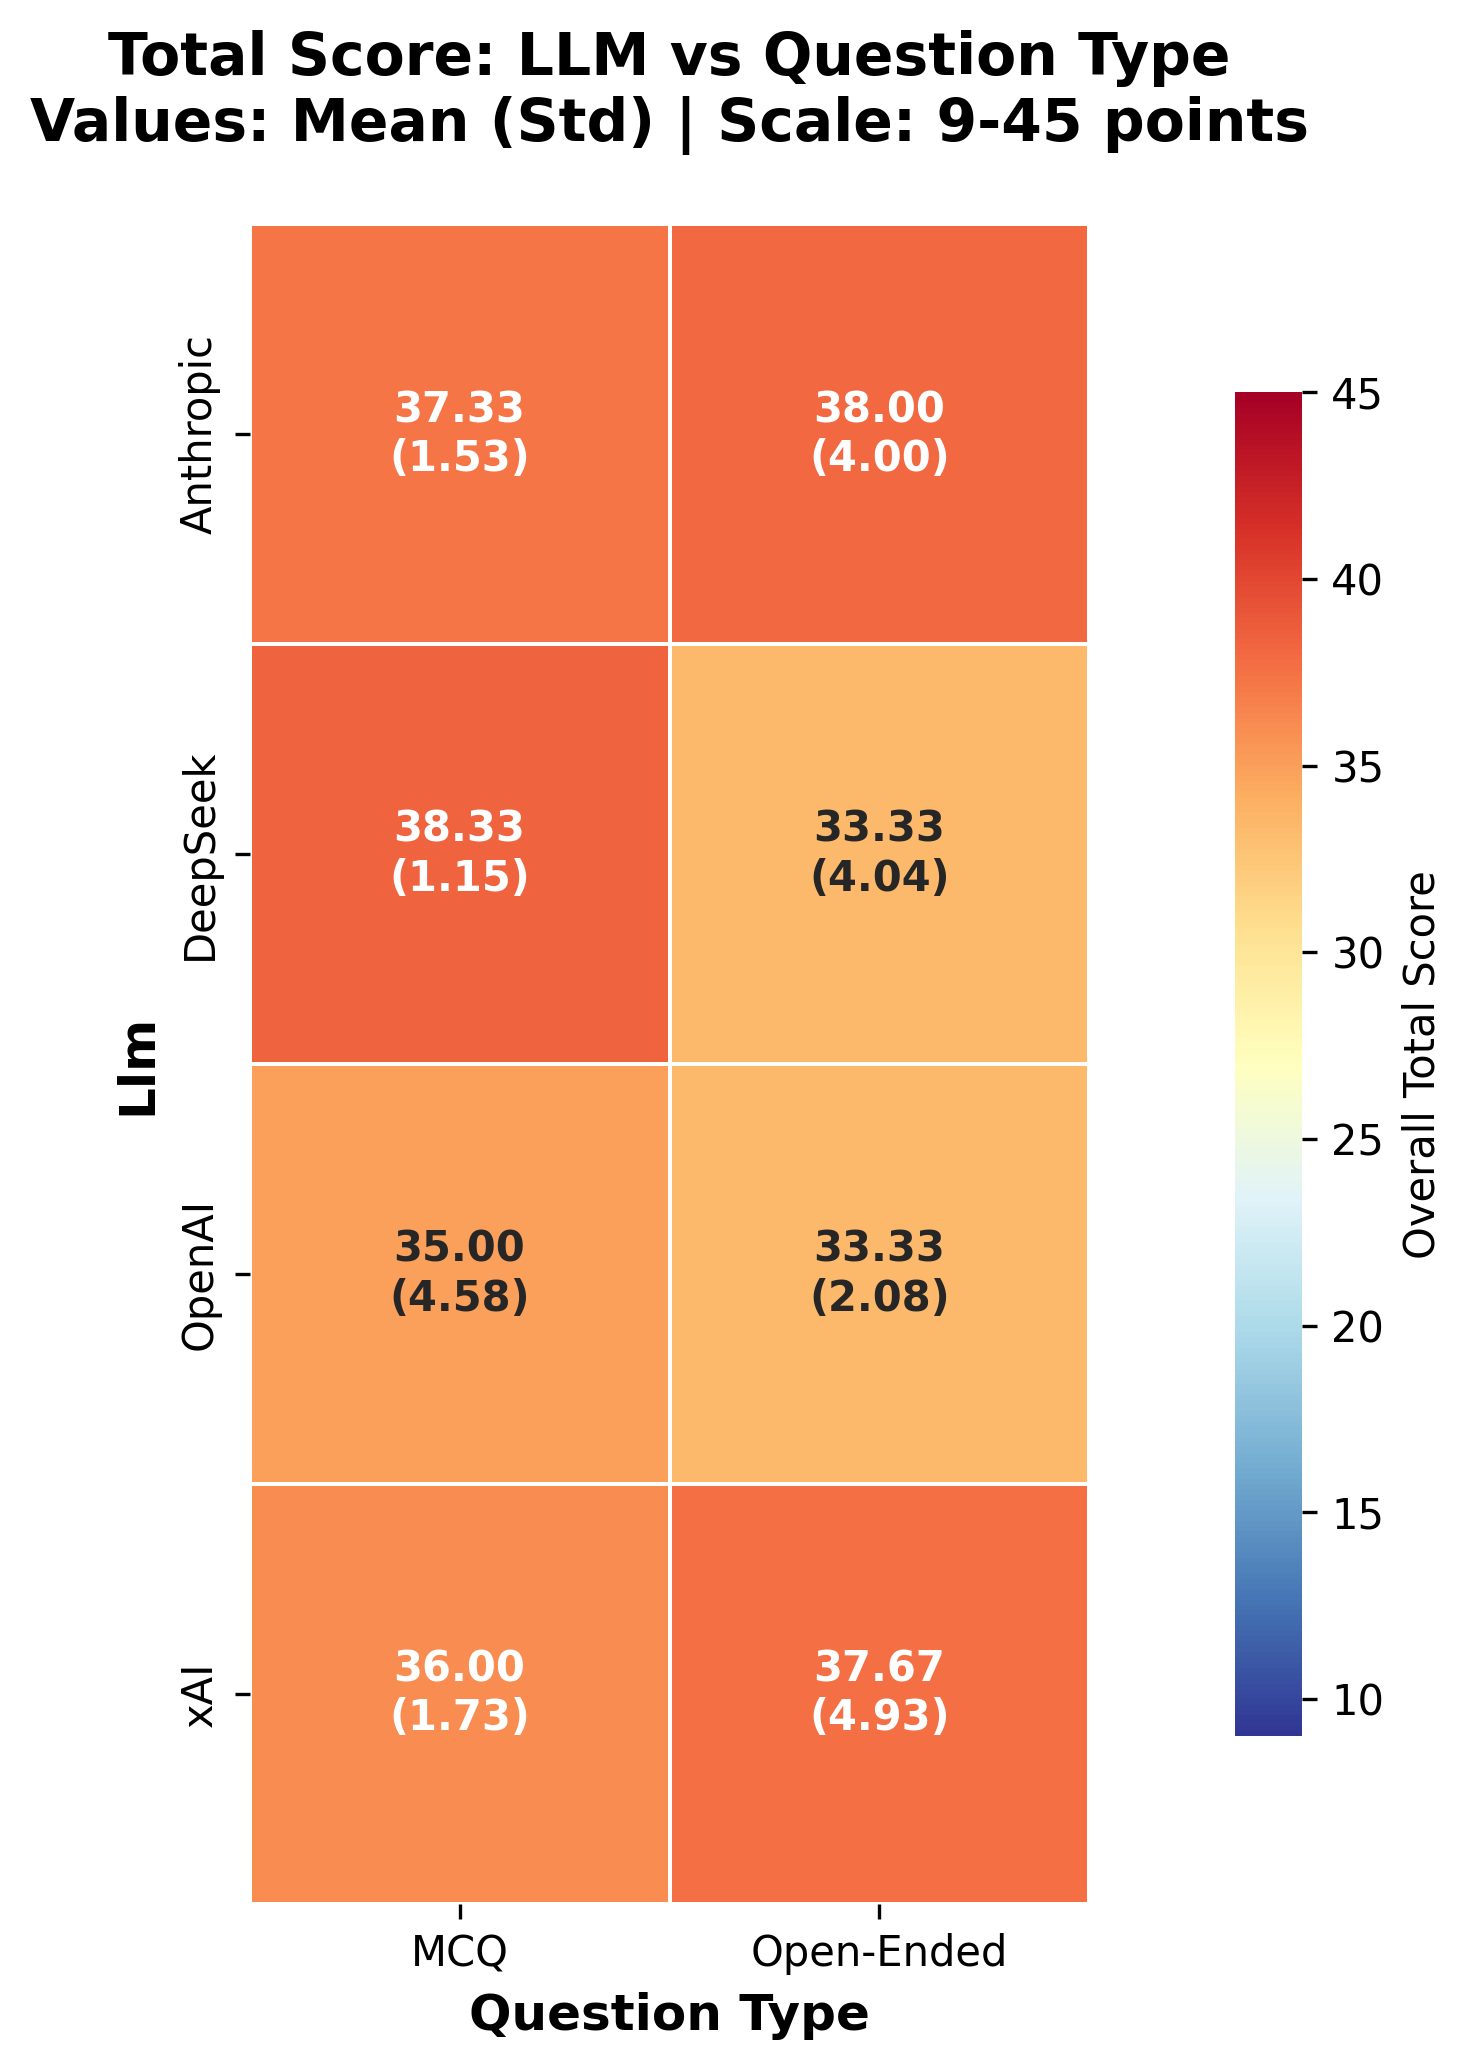

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
plots[f'exp1_total_score_heatmap_{analysis_suffix}'] = fig

create_heatmap(
    exp1_df,
    'llm',
    'question_type',
    'total_score',
    ax,
    'Total Score: LLM vs Question Type\nValues: Mean (Std) | Scale: 9-45 points',
    'Overall Total Score',
    scale_range=SCORE_RANGES['total_score'],
)

plt.tight_layout()
plt.show()

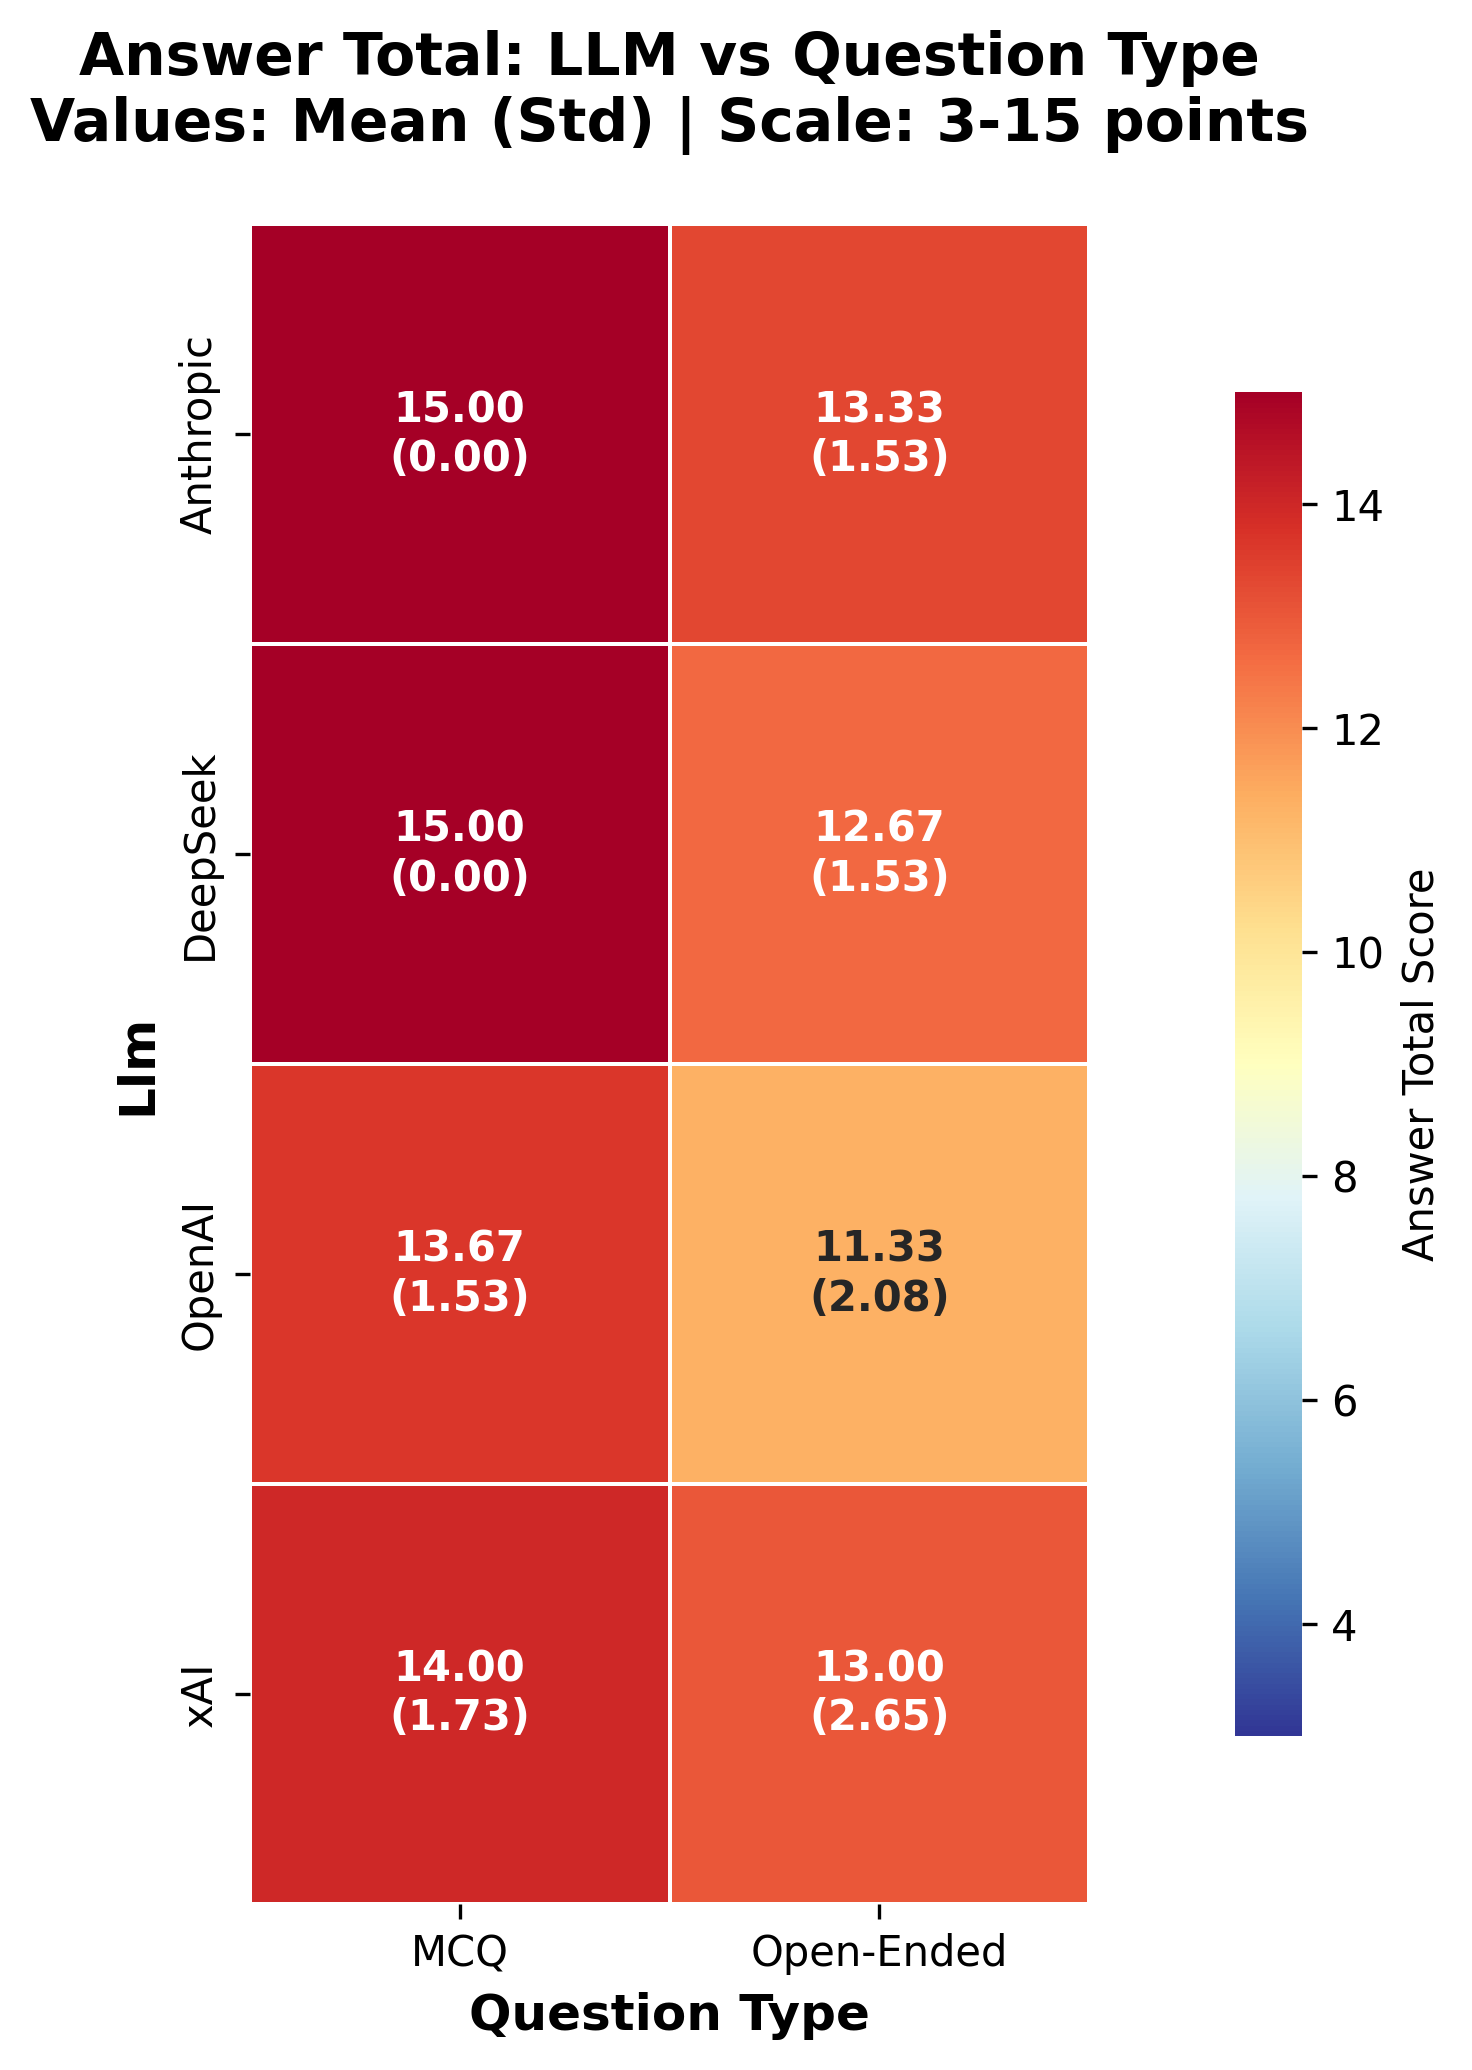

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
plots[f'exp1_answer_total_heatmap_{analysis_suffix}'] = fig

create_heatmap(
    exp1_df,
    'llm',
    'question_type',
    'answer_total_score',
    ax,
    'Answer Total: LLM vs Question Type\nValues: Mean (Std) | Scale: 3-15 points',
    'Answer Total Score',
    scale_range=SCORE_RANGES['answer_total_score'],
)

plt.tight_layout()
plt.show()

answer_llm_source_stats = exp1_df.groupby(['llm', 'input_source'])['answer_total_score'].agg(['mean', 'std', 'median', 'min', 'max', 'count']).round(2)
tables[f'exp1_answer_llm_source_stats_{analysis_suffix}'] = answer_llm_source_stats

answer_llm_question_type_stats = exp1_df.groupby(['llm', 'question_type'])['answer_total_score'].agg(['mean', 'std', 'median', 'min', 'max', 'count']).round(2)
tables[f'exp1_answer_llm_question_type_stats_{analysis_suffix}'] = answer_llm_question_type_stats

correctness_llm_question_type_stats = exp1_df.groupby(['llm', 'question_type'])['a_correctness'].agg(['mean', 'std', 'median', 'min', 'max', 'count']).round(2)
tables[f'exp1_correctness_llm_question_type_stats_{analysis_suffix}'] = correctness_llm_question_type_stats

# Inter-Rater Agreement Analysis

Agreement is computed across the unified set of 3 experts. All agreement calculations use the 1-5 Likert scale from the evaluator CSVs.

In [ ]:
print("INTER-RATER AGREEMENT ANALYSIS (Fleiss' Kappa)")
print("=" * 60)
print(f"Analyzing agreement across {len(EXPERT_IDS)} experts: {EXPERT_IDS}")

expert_dfs_dict = {
    expert_key: experts_data[expert_key]
    for expert_key in [f'expert_{expert_num}' for expert_num in EXPERT_IDS]
    if expert_key in experts_data
}

agreement_exp1 = calculate_fleiss_kappa(expert_dfs_dict, EXP1_NUMERIC_COLS)

if not agreement_exp1.empty:
    tables[f'agreement_exp1_{analysis_suffix}'] = agreement_exp1
    display(agreement_exp1.round(3))

    valid_kappas = agreement_exp1['Fleiss_Kappa'].dropna()
    if len(valid_kappas) > 0:
        avg_kappa = valid_kappas.mean()
        level = (
            "Slight" if avg_kappa < 0.2 else
            "Fair" if avg_kappa < 0.4 else
            "Moderate" if avg_kappa < 0.6 else
            "Substantial" if avg_kappa < 0.8 else
            "Almost Perfect"
        )
        print(f"\nAverage Fleiss' Kappa: {avg_kappa:.3f} ({level})")

print("\n" + "=" * 60)
print("EXPERT COMPARISON - INDIVIDUAL STATISTICS")
print("=" * 60)

expert_means = {}
available_expert_keys = [k for k in [f'expert_{n}' for n in EXPERT_IDS] if k in experts_data]

for expert_key in available_expert_keys:
    cleaned_expert_df = clean_numeric_data(experts_data[expert_key], EXP1_NUMERIC_COLS)
    cleaned_expert_df = calculate_exp1_scores(cleaned_expert_df)
    expert_means[expert_key] = cleaned_expert_df[EXP1_NUMERIC_COLS + EXP1_SCORE_COLS].mean()

comparison_df = pd.DataFrame(expert_means).T
comparison_df['overall_mean'] = comparison_df.mean(axis=1)
comparison_df = comparison_df.round(3)
tables[f'expert_comparison_exp1_{analysis_suffix}'] = comparison_df

print("\nMean Ratings by Expert (Experiment 1):")
display(comparison_df)

INTER-RATER AGREEMENT ANALYSIS (Fleiss' Kappa)
Analyzing agreement across 3 experts: [1, 2, 3]
Need at least 2 experts for agreement analysis

EXPERT COMPARISON - INDIVIDUAL STATISTICS

Mean Ratings by Expert (Experiment 1):


,q_relevance,q_clarity,q_answerability,q_challenging,q_value,q_language,a_clarity,a_language,a_correctness,question_total_score,answer_total_score,total_score,overall_mean
expert_1,4.0,4.333,3.75,2.75,3.083,4.708,4.708,4.5,4.292,22.625,13.5,36.125,9.031


In [ ]:
if 'agreement_exp1' in locals() and not agreement_exp1.empty:
    agreement_summary = agreement_exp1.groupby('Rating_Group')[['Fleiss_Kappa', 'Mean_Rating', 'Std_Rating']].mean().round(3)
    tables[f'agreement_summary_exp1_{analysis_suffix}'] = agreement_summary
    print("Average agreement by rating group:")
    display(agreement_summary)
else:
    print("No agreement summary available.")

No agreement summary available.


## Data Export

Save all tables and plots for thesis and presentations.

In [ ]:
# Save all tables and plots
for table_name, table_df in tables.items():
    if isinstance(table_df, pd.DataFrame):
        safe_name = table_name.replace(' ', '_').replace('(', '').replace(')', '').replace("'", '').lower()
        csv_path = os.path.join(output_tables_path, f'{safe_name}.csv')
        table_df.to_csv(csv_path)
        print(f'Saved table: {csv_path}')

for plot_name, fig in plots.items():
    safe_name = plot_name.replace(' ', '_').replace('(', '').replace(')', '').replace("'", '').lower()
    png_path = os.path.join(output_plots_path, f'{safe_name}.png')
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    print(f'Saved plot: {png_path}')

print(f'\nAnalysis complete. Results saved to: {output_base_path}')

Saved table: /home/malde/git/question-generation/40_evaluation/exp1/qualitative/tables/exp1_overall_stats_experts.csv
Saved table: /home/malde/git/question-generation/40_evaluation/exp1/qualitative/tables/exp1_llm_stats_experts.csv
Saved table: /home/malde/git/question-generation/40_evaluation/exp1/qualitative/tables/exp1_llm_ranking_experts.csv
Saved table: /home/malde/git/question-generation/40_evaluation/exp1/qualitative/tables/exp1_question_type_stats_experts.csv
Saved table: /home/malde/git/question-generation/40_evaluation/exp1/qualitative/tables/exp1_answer_llm_source_stats_experts.csv
Saved table: /home/malde/git/question-generation/40_evaluation/exp1/qualitative/tables/exp1_answer_llm_question_type_stats_experts.csv
Saved table: /home/malde/git/question-generation/40_evaluation/exp1/qualitative/tables/exp1_correctness_llm_question_type_stats_experts.csv
Saved table: /home/malde/git/question-generation/40_evaluation/exp1/qualitative/tables/expert_comparison_exp1_experts.csv
Sav